# AutoRec Uncertainty Experiment (ML-100K)

Compares reconstruction-residual uncertainty vs. a heteroscedastic variance head
for I-AutoRec, benchmarked as selective-prediction/abstention rules against
random and oracle baselines.

1. Reuse the repo's shared loader for ML-100K.
2. Grid search AutoRec's hyperparameters, with a heatmap of validation RMSE.
3. Run the full uncertainty/abstention experiment.

In [ ]:
import os
import random
import sys
import threading
from concurrent.futures import ThreadPoolExecutor, as_completed
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm, trange

# Walk up until we find the repo's shared loader, regardless of Jupyter's cwd.
ROOT = Path.cwd()
while not (ROOT / "dataset loaders and cleaners").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.append(str(ROOT / "dataset loaders and cleaners"))

from recsys_loader import load_split

SEED = 42


def seed_everything(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


seed_everything(SEED)

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else
    "mps" if torch.backends.mps.is_available() else
    "cpu"
)
print(f"Device: {DEVICE}")

# The grid/dropout searches below run many independent configs at once via
# ThreadPoolExecutor: PyTorch's CPU kernels release the GIL during the actual
# matmul/etc., so real threads give real parallelism, unlike plain Python
# code. Each worker trains with torch.set_num_threads(1) so it doesn't try to
# intra-op-parallelize its own small matmuls - N_WORKERS single-threaded jobs
# spread across all logical cores beats one job awkwardly fighting itself
# over 20 threads for a 610-wide matrix. seed_everything() touches PyTorch's
# *global* RNG, so weight init is serialized behind init_lock (cheap) while
# training itself (expensive) runs fully in parallel.
N_WORKERS = os.cpu_count()
init_lock = threading.Lock()
print(f"N_WORKERS: {N_WORKERS}")

## 1. Data: ML-100K via the shared loader

Uses `recsys_loader.load_split`, the same 70/20/10 proposal-protocol split
every other method script in this repo uses, instead of hand-rolling a fresh
download/split.

**Note:** this loads as 610 users x 9,724 items - that's MovieLens-latest-small's
shape, not the classic GroupLens ML-100K (943 users x 1,682 items) that most
published AutoRec numbers (e.g. D2L's 0.900 test RMSE) were computed on. Much
sparser per item, so don't expect published ML-100K RMSEs to be a hard target
here - they're a rough compass, not an apples-to-apples bar.

In [11]:
split = load_split("ml-100k", seed=SEED)
print(
    f"ml-100k: users={split.n_users:,} items={split.n_items:,} "
    f"train={len(split.train):,} val={len(split.val):,} test={len(split.test):,}"
)


def build_item_user_matrix(rows: np.ndarray, n_users: int, n_items: int):
    """I-AutoRec orientation: matrix[item, user] = rating, 0 where unobserved."""
    matrix = np.zeros((n_items, n_users), dtype=np.float32)
    mask = np.zeros((n_items, n_users), dtype=bool)
    u = rows[:, 0].astype(np.int64)
    i = rows[:, 1].astype(np.int64)
    r = rows[:, 2].astype(np.float32)
    matrix[i, u] = r
    mask[i, u] = True
    return matrix, mask


train_matrix, train_mask = build_item_user_matrix(split.train, split.n_users, split.n_items)
val_matrix, val_mask = build_item_user_matrix(split.val, split.n_users, split.n_items)
test_matrix, test_mask = build_item_user_matrix(split.test, split.n_users, split.n_items)

trainval_rows = np.concatenate([split.train, split.val], axis=0)
trainval_matrix, trainval_mask = build_item_user_matrix(trainval_rows, split.n_users, split.n_items)

train_matrix_t = torch.from_numpy(train_matrix)
trainval_matrix_t = torch.from_numpy(trainval_matrix)

ml-100k: users=610 items=9,724 train=70,585 val=20,167 test=10,084


## Models & losses

Vanilla I-AutoRec (sigmoid encoder, dropout, linear decoder) and a
heteroscedastic variant with separate mean/variance decoder heads, trained
with Gaussian NLL.

In [12]:
def init_autorec_weights(module: nn.Module) -> None:
    if isinstance(module, nn.Linear):
        nn.init.normal_(module.weight, mean=0.0, std=0.01)
        if module.bias is not None:
            nn.init.zeros_(module.bias)


class AutoRec(nn.Module):
    """Vanilla item-based AutoRec: x -> sigmoid encoder -> dropout -> linear decoder."""

    def __init__(self, num_users: int, hidden_dim: int = 500, dropout: float = 0.05):
        super().__init__()
        self.encoder = nn.Linear(num_users, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.decoder = nn.Linear(hidden_dim, num_users)
        self.apply(init_autorec_weights)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        h = torch.sigmoid(self.encoder(x))
        h = self.dropout(h)
        return self.decoder(h)


class HeteroscedasticAutoRec(nn.Module):
    """Same encoder, two decoder heads: mean_head -> mu(x), var_head -> variance(x) > 0
    (parameterized via softplus so it's always positive)."""

    def __init__(self, num_users: int, hidden_dim: int = 500, dropout: float = 0.05):
        super().__init__()
        self.encoder = nn.Linear(num_users, hidden_dim)
        self.dropout = nn.Dropout(dropout)
        self.mean_decoder = nn.Linear(hidden_dim, num_users)
        self.raw_var_decoder = nn.Linear(hidden_dim, num_users)
        self.apply(init_autorec_weights)
        nn.init.zeros_(self.raw_var_decoder.bias)  # raw_var=0 -> softplus(0)~=0.693 variance initially

    def forward(self, x: torch.Tensor):
        h = torch.sigmoid(self.encoder(x))
        h = self.dropout(h)
        mu = self.mean_decoder(h)
        raw_var = self.raw_var_decoder(h)
        var = F.softplus(raw_var) + 1e-4
        return mu, var


def masked_mse(pred: torch.Tensor, actual: torch.Tensor) -> torch.Tensor:
    mask = actual > 0
    return ((pred - actual) ** 2)[mask].mean()


def masked_gaussian_nll(mu: torch.Tensor, var: torch.Tensor, actual: torch.Tensor) -> torch.Tensor:
    """0.5 * [log(var) + (y - mu)^2 / var], observed ratings only (constant term dropped)."""
    mask = actual > 0
    nll = 0.5 * (torch.log(var) + ((actual - mu) ** 2) / var)
    return nll[mask].mean()


def masked_rmse(pred: torch.Tensor, actual: torch.Tensor, mask: torch.Tensor) -> float:
    diff = (pred - actual)[mask]
    return torch.sqrt(torch.mean(diff**2)).item()

## Training loops

Full-batch (every item every step, like the rest of this repo's method
scripts) with early stopping on validation RMSE, and a pretty `tqdm` bar per
run.

In [13]:
def train_vanilla(model, train_x, val_matrix, val_mask, device, max_epochs, lr, weight_decay, patience, desc=None, show_progress=True):
    model.to(device)
    train_x = train_x.to(device)
    val_matrix_t = torch.from_numpy(val_matrix).to(device)
    val_mask_t = torch.from_numpy(val_mask).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_rmse, best_state, best_epoch = float("inf"), None, -1
    bar = trange(max_epochs, desc=desc or "vanilla", leave=False, disable=not show_progress)
    for epoch in bar:
        model.train()
        opt.zero_grad()
        pred = model(train_x)
        loss = masked_mse(pred, train_x)
        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            pred = model(train_x)
            v_rmse = masked_rmse(pred, val_matrix_t, val_mask_t)
        bar.set_postfix(val_rmse=f"{v_rmse:.4f}", best=f"{best_rmse:.4f}")

        if v_rmse < best_rmse - 1e-5:
            best_rmse, best_epoch = v_rmse, epoch
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        elif epoch - best_epoch >= patience:
            break

    model.load_state_dict(best_state)
    return model, best_rmse


def train_hetero(model, train_x, val_matrix, val_mask, device, max_epochs, lr, weight_decay, patience, desc=None, show_progress=True):
    model.to(device)
    train_x = train_x.to(device)
    val_matrix_t = torch.from_numpy(val_matrix).to(device)
    val_mask_t = torch.from_numpy(val_mask).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_rmse, best_state, best_epoch = float("inf"), None, -1
    bar = trange(max_epochs, desc=desc or "hetero", leave=False, disable=not show_progress)
    for epoch in bar:
        model.train()
        opt.zero_grad()
        mu, var = model(train_x)
        loss = masked_gaussian_nll(mu, var, train_x)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)  # protects the variance head early on
        opt.step()

        model.eval()
        with torch.no_grad():
            mu, _ = model(train_x)
            v_rmse = masked_rmse(mu, val_matrix_t, val_mask_t)
        bar.set_postfix(val_rmse=f"{v_rmse:.4f}", best=f"{best_rmse:.4f}")

        if v_rmse < best_rmse - 1e-5:
            best_rmse, best_epoch = v_rmse, epoch
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}
        elif epoch - best_epoch >= patience:
            break

    model.load_state_dict(best_state)
    return model, best_rmse

## 2. Hyperparameter search: backbone grid + dropout refinement, with heatmaps

Two stages, to stay out of combinatorial-explosion territory while still being
much more thorough than a single small grid:

- **Stage 1**: grid search `hidden` x `lr` x `weight_decay` for the vanilla
  backbone (dropout fixed), scored by validation RMSE. The old 60-epoch/
  patience-8 budget was cutting off the lower-`lr` configs before they'd
  actually converged - that's most of why the old heatmap had so many "huge"
  values. This one trains much longer per config.
- **Stage 2**: sweep `dropout` at the Stage 1 winner. Dropout was never tuned
  before (fixed at 0.05, carried over from D2L's defaults) - it matters here
  since `hidden` is often close to or larger than the input dimension (610
  users), so this backbone is frequently over- rather than under-complete.

The heteroscedastic model reuses the winning `(hidden, lr, weight_decay,
dropout)` config, same as the original script's design intent.

In [ ]:
HIDDEN_GRID = [50, 100, 200, 300, 500, 750]
LR_GRID = [5e-4, 1e-3, 2e-3, 3e-3, 5e-3, 8e-3, 1e-2, 1.5e-2]
WD_GRID = [0.0, 1e-5, 1e-4, 1e-3]
DROPOUT = 0.05  # fixed for Stage 1; tuned in Stage 2 below
GRID_MAX_EPOCHS = 300
GRID_PATIENCE = 25

configs = [(h, lr, wd) for h in HIDDEN_GRID for lr in LR_GRID for wd in WD_GRID]
grid_rmse = np.full((len(HIDDEN_GRID), len(LR_GRID), len(WD_GRID)), np.nan)


def run_stage1_config(h, lr, wd):
    with init_lock:
        seed_everything(SEED)
        model = AutoRec(split.n_users, hidden_dim=h, dropout=DROPOUT)
    _, v_rmse = train_vanilla(
        model, train_matrix_t, val_matrix, val_mask, DEVICE,
        max_epochs=GRID_MAX_EPOCHS, lr=lr, weight_decay=wd, patience=GRID_PATIENCE,
        show_progress=False,
    )
    return h, lr, wd, v_rmse


torch.set_num_threads(1)  # each worker does its own single-threaded matmuls; ThreadPoolExecutor supplies the parallelism

best_cfg, best_val_rmse = None, float("inf")
with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
    futures = [pool.submit(run_stage1_config, h, lr, wd) for h, lr, wd in configs]
    for fut in tqdm(as_completed(futures), total=len(futures), desc=f"stage 1: backbone grid search ({N_WORKERS} workers)"):
        h, lr, wd, v_rmse = fut.result()
        grid_rmse[HIDDEN_GRID.index(h), LR_GRID.index(lr), WD_GRID.index(wd)] = v_rmse
        if v_rmse < best_val_rmse:
            best_val_rmse, best_cfg = v_rmse, {"hidden": h, "lr": lr, "weight_decay": wd}

torch.set_num_threads(N_WORKERS)  # restore for the sequential final-refit cells later

print(f"stage 1 best backbone: {best_cfg} (val RMSE={best_val_rmse:.4f})")

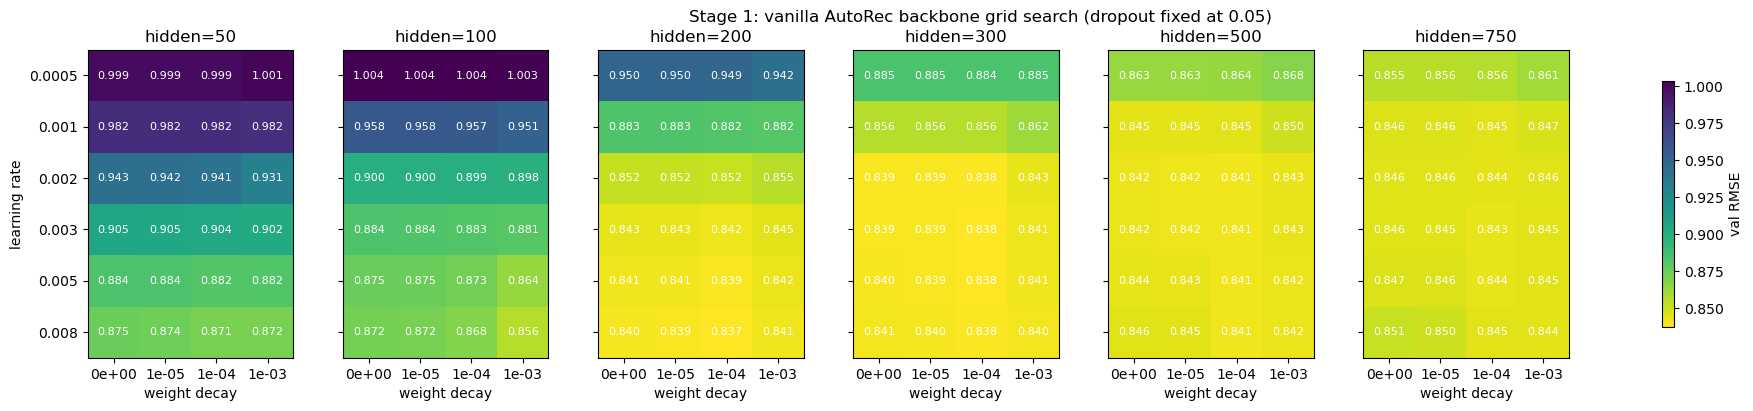

In [15]:
fig, axes = plt.subplots(1, len(HIDDEN_GRID), figsize=(4 * len(HIDDEN_GRID), 4), sharey=True)
vmin, vmax = np.nanmin(grid_rmse), np.nanmax(grid_rmse)
im = None
for ax, h in zip(axes, HIDDEN_GRID):
    im = ax.imshow(grid_rmse[HIDDEN_GRID.index(h)], cmap="viridis_r", vmin=vmin, vmax=vmax)
    ax.set_title(f"hidden={h}")
    ax.set_xticks(range(len(WD_GRID)))
    ax.set_xticklabels([f"{wd:.0e}" for wd in WD_GRID])
    ax.set_xlabel("weight decay")
    ax.set_yticks(range(len(LR_GRID)))
    ax.set_yticklabels([str(lr) for lr in LR_GRID])
    for i in range(len(LR_GRID)):
        for j in range(len(WD_GRID)):
            val = grid_rmse[HIDDEN_GRID.index(h), i, j]
            ax.text(j, i, f"{val:.3f}", ha="center", va="center", color="white", fontsize=8)
axes[0].set_ylabel("learning rate")
fig.colorbar(im, ax=axes, label="val RMSE", shrink=0.8)
fig.suptitle(f"Stage 1: vanilla AutoRec backbone grid search (dropout fixed at {DROPOUT})")
plt.savefig("autorec_gridsearch_heatmap.png", dpi=160, bbox_inches="tight")
plt.show()

In [ ]:
DROPOUT_GRID = [0.0, 0.02, 0.05, 0.1, 0.15, 0.2, 0.3, 0.4, 0.5, 0.6]


def run_stage2_config(dr):
    with init_lock:
        seed_everything(SEED)
        model = AutoRec(split.n_users, hidden_dim=best_cfg["hidden"], dropout=dr)
    _, v_rmse = train_vanilla(
        model, train_matrix_t, val_matrix, val_mask, DEVICE,
        max_epochs=GRID_MAX_EPOCHS, lr=best_cfg["lr"], weight_decay=best_cfg["weight_decay"],
        patience=GRID_PATIENCE, show_progress=False,
    )
    return dr, v_rmse


torch.set_num_threads(1)

dropout_rmse_by_value = {}
with ThreadPoolExecutor(max_workers=N_WORKERS) as pool:
    futures = [pool.submit(run_stage2_config, dr) for dr in DROPOUT_GRID]
    for fut in tqdm(as_completed(futures), total=len(futures), desc=f"stage 2: dropout sweep ({N_WORKERS} workers)"):
        dr, v_rmse = fut.result()
        dropout_rmse_by_value[dr] = v_rmse

torch.set_num_threads(N_WORKERS)  # restore for the sequential final-refit cells later

dropout_rmse = [dropout_rmse_by_value[dr] for dr in DROPOUT_GRID]

best_dropout_rmse = min(dropout_rmse)
DROPOUT = DROPOUT_GRID[int(np.argmin(dropout_rmse))]
print(f"stage 2 best dropout: {DROPOUT} (val RMSE={best_dropout_rmse:.4f})")

plt.figure(figsize=(6, 4))
plt.plot(DROPOUT_GRID, dropout_rmse, marker="o")
plt.axvline(DROPOUT, color="red", linestyle="--", alpha=0.6, label=f"best={DROPOUT}")
plt.xlabel("dropout")
plt.ylabel("val RMSE")
plt.title(f"Stage 2: dropout sweep at hidden={best_cfg['hidden']}, lr={best_cfg['lr']}, wd={best_cfg['weight_decay']:.0e}")
plt.legend()
plt.tight_layout()
plt.savefig("autorec_dropout_sweep.png", dpi=160)
plt.show()

print(
    f"\nFinal chosen config: hidden={best_cfg['hidden']}, lr={best_cfg['lr']}, "
    f"weight_decay={best_cfg['weight_decay']:.0e}, dropout={DROPOUT} "
    f"(val RMSE={min(best_val_rmse, best_dropout_rmse):.4f})"
)

## 3. Final experiment: selective prediction / abstention

Refit both models on train+val with the winning hyperparameters, evaluate on
the held-out test set, and compare uncertainty-ranked abstention against
random and oracle baselines.

In [17]:
def vanilla_residual_uncertainty(obs_matrix: np.ndarray, pred_matrix: np.ndarray):
    """Reconstruction-residual uncertainty from observed entries only.
    item_score[i] = mean squared residual over item i's observed users;
    user_score[u] likewise over user u's observed items."""
    mask = obs_matrix > 0
    sq = (pred_matrix - obs_matrix) ** 2

    item_score = (sq * mask).sum(axis=1) / np.maximum(mask.sum(axis=1), 1)
    user_score = (sq * mask).sum(axis=0) / np.maximum(mask.sum(axis=0), 1)
    return item_score, user_score


def extract_test_arrays(test_rows: np.ndarray, pred_matrix: np.ndarray):
    users = test_rows[:, 0].astype(np.int64)
    items = test_rows[:, 1].astype(np.int64)
    y = test_rows[:, 2].astype(np.float32)
    pred = pred_matrix[items, users]
    return y, pred, users, items


def rmse(y: np.ndarray, pred: np.ndarray) -> float:
    return float(np.sqrt(np.mean((y - pred) ** 2)))


def spearman_rank_corr(a: np.ndarray, b: np.ndarray) -> float:
    ra = pd.Series(a).rank(method="average").to_numpy()
    rb = pd.Series(b).rank(method="average").to_numpy()
    if np.std(ra) == 0 or np.std(rb) == 0:
        return float("nan")
    return float(np.corrcoef(ra, rb)[0, 1])


def selective_curve(y, pred, uncertainty, coverages, label):
    """Keep the LOWEST-uncertainty predictions; coverage=0.8 abstains on the highest-uncertainty 20%."""
    order = np.argsort(uncertainty)
    n = len(y)
    rows = []
    for c in coverages:
        k = max(1, int(round(c * n)))
        keep = order[:k]
        rows.append({"method": label, "coverage": float(c), "abstain_frac": float(1.0 - c),
                     "n_kept": int(k), "rmse": rmse(y[keep], pred[keep])})
    return rows


def random_selective_curve(y, pred, coverages, seed, repeats=100):
    rng = np.random.default_rng(seed)
    n = len(y)
    rows = []
    for c in tqdm(coverages, desc="random abstention", leave=False):
        k = max(1, int(round(c * n)))
        vals = []
        for _ in range(repeats):
            keep = rng.choice(n, size=k, replace=False)
            vals.append(rmse(y[keep], pred[keep]))
        rows.append({"method": "random abstention (vanilla pred)", "coverage": float(c),
                     "abstain_frac": float(1.0 - c), "n_kept": int(k), "rmse": float(np.mean(vals))})
    return rows


def oracle_selective_curve(y, pred, coverages):
    """Not a real method: ranks by true test error. Upper-bound sanity check only."""
    true_err2 = (y - pred) ** 2
    return selective_curve(y, pred, true_err2, coverages, label="oracle error ranking (not usable)")


def print_curve_table(results: pd.DataFrame) -> None:
    pivot = results.pivot(index="coverage", columns="method", values="rmse").sort_index(ascending=False)
    print("\nSelective RMSE (lower is better):")
    print(pivot.round(4).to_string())


def plot_curves(results: pd.DataFrame, out_path: Path) -> None:
    plt.figure(figsize=(8, 5))
    for method, g in results.groupby("method"):
        g = g.sort_values("coverage")
        plt.plot(g["coverage"], g["rmse"], marker="o", label=method)
    plt.xlabel("Coverage (fraction of predictions kept)")
    plt.ylabel("RMSE on kept predictions")
    plt.title("MovieLens 100K: selective prediction / abstention")
    plt.legend()
    plt.tight_layout()
    plt.savefig(out_path, dpi=160)
    plt.show()

In [18]:
FINAL_MAX_EPOCHS = 400
FINAL_PATIENCE = 30
CLIP_PREDICTIONS = True  # clip predicted means to the valid rating range [1, 5]

seed_everything(SEED)
vanilla = AutoRec(split.n_users, hidden_dim=best_cfg["hidden"], dropout=DROPOUT)
vanilla, _ = train_vanilla(
    vanilla, trainval_matrix_t, test_matrix, test_mask, DEVICE,
    max_epochs=FINAL_MAX_EPOCHS, lr=best_cfg["lr"], weight_decay=best_cfg["weight_decay"],
    patience=FINAL_PATIENCE, desc="vanilla refit (train+val)", show_progress=True,
)
with torch.no_grad():
    vanilla.eval()
    vanilla_matrix = vanilla(trainval_matrix_t.to(DEVICE)).cpu().numpy()
if CLIP_PREDICTIONS:
    vanilla_matrix = np.clip(vanilla_matrix, 1.0, 5.0)

y, vanilla_pred, users, items = extract_test_arrays(split.test, vanilla_matrix)
print(f"\nVanilla AutoRec test RMSE: {rmse(y, vanilla_pred):.4f}")

item_resid, user_resid = vanilla_residual_uncertainty(trainval_matrix, vanilla_matrix)
residual_item_u = item_resid[items]
residual_user_item_u = 0.5 * (item_resid[items] + user_resid[users])

seed_everything(SEED)
hetero = HeteroscedasticAutoRec(split.n_users, hidden_dim=best_cfg["hidden"], dropout=DROPOUT)
hetero, _ = train_hetero(
    hetero, trainval_matrix_t, test_matrix, test_mask, DEVICE,
    max_epochs=FINAL_MAX_EPOCHS, lr=best_cfg["lr"], weight_decay=best_cfg["weight_decay"],
    patience=FINAL_PATIENCE, desc="hetero refit (train+val)", show_progress=True,
)
with torch.no_grad():
    hetero.eval()
    hetero_mu_matrix, hetero_var_matrix = hetero(trainval_matrix_t.to(DEVICE))
    hetero_mu_matrix = hetero_mu_matrix.cpu().numpy()
    hetero_var_matrix = hetero_var_matrix.cpu().numpy()
if CLIP_PREDICTIONS:
    hetero_mu_matrix = np.clip(hetero_mu_matrix, 1.0, 5.0)

_, hetero_pred, _, _ = extract_test_arrays(split.test, hetero_mu_matrix)
hetero_var = hetero_var_matrix[items, users]

print(f"Heteroscedastic AutoRec test RMSE: {rmse(y, hetero_pred):.4f}")
z2 = ((y - hetero_pred) ** 2) / hetero_var
print(f"Hetero calibration check, mean[(error^2)/var]: {np.mean(z2):.3f}  (ideal-ish: ~1)")

vanilla refit (train+val):   0%|          | 0/400 [00:00<?, ?it/s]


Vanilla AutoRec test RMSE: 0.8288


hetero refit (train+val):   0%|          | 0/400 [00:00<?, ?it/s]

Heteroscedastic AutoRec test RMSE: 0.8263
Hetero calibration check, mean[(error^2)/var]: 1.045  (ideal-ish: ~1)



Spearman correlation: uncertainty vs squared test error
  residual(item):      0.0540
  residual(user+item): 0.2047
  heteroscedastic var: 0.3097


random abstention:   0%|          | 0/6 [00:00<?, ?it/s]


Selective RMSE (lower is better):
method    heteroscedastic variance  oracle error ranking (not usable)  random abstention (vanilla pred)  residual uncertainty: item  residual uncertainty: user+item
coverage                                                                                                                                                            
1.0                         0.8263                             0.8288                            0.8288                      0.8288                           0.8288
0.9                         0.7698                             0.6174                            0.8288                      0.8160                           0.7881
0.8                         0.7320                             0.5087                            0.8289                      0.8058                           0.7549
0.7                         0.7050                             0.4243                            0.8287                      0.7953         

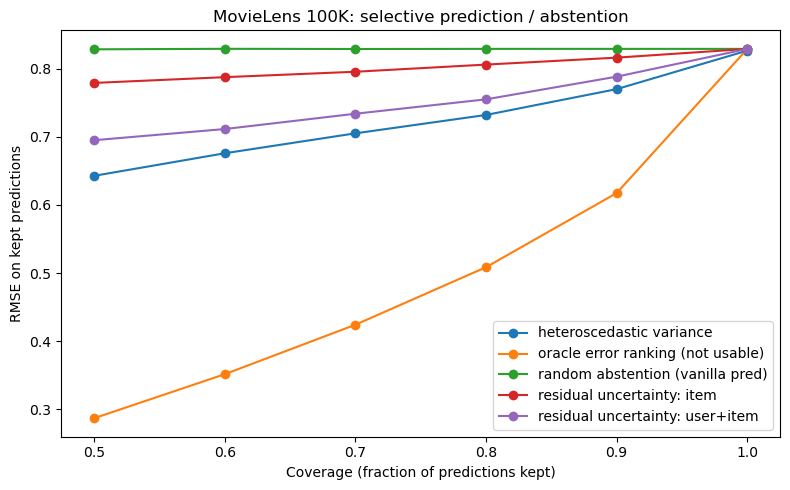


Saved: C:\Users\user\Documents\SMU new!\Researrch\theGreatTry\week4\autorec_selective_results.csv
Saved: C:\Users\user\Documents\SMU new!\Researrch\theGreatTry\week4\autorec_uncertainty_curve.png

Interpretation:
  * At 100% coverage, abstention does nothing.
  * As coverage falls, a useful uncertainty score should make RMSE fall
    faster than random abstention.
  * Positive Spearman correlation means higher uncertainty tends to
    coincide with larger prediction errors.
  * The oracle line is unattainable in practice; it just shows what
    perfect error-ranking would look like.
  * The residual(item) score is exactly item-level for I-AutoRec: every
    missing rating for the same item gets the same score.
  * The residual(user+item) score is an extra heuristic to make the
    residual signal target-specific.
  * Heteroscedastic variance is directly target-specific U_ui.



In [19]:
vanilla_err2 = (y - vanilla_pred) ** 2
hetero_err2 = (y - hetero_pred) ** 2

print("\nSpearman correlation: uncertainty vs squared test error")
print(f"  residual(item):      {spearman_rank_corr(residual_item_u, vanilla_err2):.4f}")
print(f"  residual(user+item): {spearman_rank_corr(residual_user_item_u, vanilla_err2):.4f}")
print(f"  heteroscedastic var: {spearman_rank_corr(hetero_var, hetero_err2):.4f}")

coverages = [1.00, 0.90, 0.80, 0.70, 0.60, 0.50]
rows = []
rows += selective_curve(y, vanilla_pred, residual_item_u, coverages, label="residual uncertainty: item")
rows += selective_curve(y, vanilla_pred, residual_user_item_u, coverages, label="residual uncertainty: user+item")
rows += selective_curve(y, hetero_pred, hetero_var, coverages, label="heteroscedastic variance")
rows += random_selective_curve(y, vanilla_pred, coverages, seed=SEED + 123, repeats=100)
rows += oracle_selective_curve(y, vanilla_pred, coverages)

results = pd.DataFrame(rows)
print_curve_table(results)

csv_path = Path("autorec_selective_results.csv")
fig_path = Path("autorec_uncertainty_curve.png")
results.to_csv(csv_path, index=False)
plot_curves(results, fig_path)
print(f"\nSaved: {csv_path.resolve()}")
print(f"Saved: {fig_path.resolve()}")

print(
    "\nInterpretation:\n"
    "  * At 100% coverage, abstention does nothing.\n"
    "  * As coverage falls, a useful uncertainty score should make RMSE fall\n"
    "    faster than random abstention.\n"
    "  * Positive Spearman correlation means higher uncertainty tends to\n"
    "    coincide with larger prediction errors.\n"
    "  * The oracle line is unattainable in practice; it just shows what\n"
    "    perfect error-ranking would look like.\n"
    "  * The residual(item) score is exactly item-level for I-AutoRec: every\n"
    "    missing rating for the same item gets the same score.\n"
    "  * The residual(user+item) score is an extra heuristic to make the\n"
    "    residual signal target-specific.\n"
    "  * Heteroscedastic variance is directly target-specific U_ui.\n"
)